# 05 - E5 Baseline mejorado binario

**Objetivo:** construir un baseline binario 2D mejorado sobre slices sagitales de SPIDER, corrigiendo limitaciones detectadas en el diagnostico anterior.

Este notebook evalua si mejora el flujo al usar mas casos, GPU si esta disponible, mas epocas, perdida con manejo explicito del desbalance y seleccion automatica de threshold.

**Fuera de alcance:** multiclase, axial, nnU-Net, integracion backend y producto final.

## 1. Instalacion e importacion de dependencias

In [1]:
!pip -q install SimpleITK scikit-image tqdm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.8/52.8 MB 17.2 MB/s eta 0:00:00


In [2]:
from pathlib import Path
import json
import random
import warnings

import SimpleITK as sitk
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from skimage.transform import resize
from tqdm.auto import tqdm

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, random_split

warnings.filterwarnings("ignore")

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

print("PyTorch:", torch.__version__)
print("SimpleITK:", sitk.Version())

PyTorch: 2.11.0+cpu
SimpleITK: SimpleITK Version: 2.5.5 (ITK 5.4)
Compiled: May 12 2026 17:19:38



## 2. Verificacion de entorno y rutas

In [3]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("CUDA disponible:", torch.cuda.is_available())
print("Dispositivo:", DEVICE)
if DEVICE.type == "cpu":
    print("ADVERTENCIA: no se detecto GPU. El notebook puede correr en CPU, pero sera mas lento.")

CUDA disponible: False
Dispositivo: cpu
ADVERTENCIA: no se detecto GPU. El notebook puede correr en CPU, pero sera mas lento.


In [4]:
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


In [5]:
DATASET_ROOT = Path("/content/drive/MyDrive/PFI_MVP/data/SPIDER")
PREPROCESS_ROOT = Path("/content/drive/MyDrive/PFI_MVP/results/E4_preprocesamiento")
BASELINE_ROOT = Path("/content/drive/MyDrive/PFI_MVP/results/E5_baseline_sagital")
IMPROVED_ROOT = Path("/content/drive/MyDrive/PFI_MVP/results/E5_baseline_mejorado_binario")
FIGURES_ROOT = Path("/content/drive/MyDrive/PFI_MVP/figures")
DOCS_ROOT = Path("/content/drive/MyDrive/PFI_MVP/docs")

for path in [IMPROVED_ROOT, FIGURES_ROOT, DOCS_ROOT]:
    path.mkdir(parents=True, exist_ok=True)

CANDIDATES_CSV = PREPROCESS_ROOT / "E4_baseline_candidates_no_space.csv"
BASELINE_THRESHOLD_SUMMARY_CSV = BASELINE_ROOT / "E5_threshold_summary.csv"

print("DATASET_ROOT:", DATASET_ROOT)
print("PREPROCESS_ROOT:", PREPROCESS_ROOT)
print("BASELINE_ROOT:", BASELINE_ROOT)
print("IMPROVED_ROOT:", IMPROVED_ROOT)
print("FIGURES_ROOT:", FIGURES_ROOT)
print("DOCS_ROOT:", DOCS_ROOT)
print("CANDIDATES_CSV:", CANDIDATES_CSV)

DATASET_ROOT: /content/drive/MyDrive/PFI_MVP/data/SPIDER
PREPROCESS_ROOT: /content/drive/MyDrive/PFI_MVP/results/E4_preprocesamiento
BASELINE_ROOT: /content/drive/MyDrive/PFI_MVP/results/E5_baseline_sagital
IMPROVED_ROOT: /content/drive/MyDrive/PFI_MVP/results/E5_baseline_mejorado_binario
FIGURES_ROOT: /content/drive/MyDrive/PFI_MVP/figures
DOCS_ROOT: /content/drive/MyDrive/PFI_MVP/docs
CANDIDATES_CSV: /content/drive/MyDrive/PFI_MVP/results/E4_preprocesamiento/E4_baseline_candidates_no_space.csv


## 3. Carga de candidatos

In [6]:
MODALITY_FILTER = "t1"  # opciones: "t1", "t2", "both"
N_CASES = 100
SAGITTAL_AXIS = 2
TARGET_SIZE = (256, 256)
BATCH_SIZE = 4
EPOCHS = 20
LEARNING_RATE = 1e-3
BASE_CHANNELS = 16
THRESHOLDS = [0.3, 0.4, 0.5, 0.6, 0.7]

candidates_df = pd.read_csv(CANDIDATES_CSV)

def infer_case_modality(row):
    text = " ".join(str(v).lower() for v in row.values)
    if "t2" in text:
        return "t2"
    if "t1" in text:
        return "t1"
    return "unknown"


work_df = candidates_df.copy()
if "modality" not in work_df.columns:
    work_df["modality"] = work_df.apply(infer_case_modality, axis=1)

if MODALITY_FILTER != "both":
    filtered_df = work_df[work_df["modality"].str.lower().eq(MODALITY_FILTER)].copy()
else:
    filtered_df = work_df.copy()

if len(filtered_df) == 0:
    raise RuntimeError(f"No hay candidatos para MODALITY_FILTER={MODALITY_FILTER}.")

selected_df = filtered_df.sample(n=min(N_CASES, len(filtered_df)), random_state=SEED).reset_index(drop=True)
selected_cases_csv_path = IMPROVED_ROOT / "E5_improved_selected_cases.csv"
selected_df.to_csv(selected_cases_csv_path, index=False)

print("Candidatos totales:", len(candidates_df))
print("Filtro modalidad:", MODALITY_FILTER)
print("Candidatos filtrados:", len(filtered_df))
print("Casos seleccionados:", len(selected_df))
print("CSV casos seleccionados:", selected_cases_csv_path)
display(selected_df.head())

Candidatos totales: 406
Filtro modalidad: t1
Candidatos filtrados: 196
Casos seleccionados: 100
CSV casos seleccionados: /content/drive/MyDrive/PFI_MVP/results/E5_baseline_mejorado_binario/E5_improved_selected_cases.csv


,case_id,image_path,mask_path,image_shape_zyx,mask_shape_zyx,same_shape,image_spacing_xyz,mask_spacing_xyz,same_spacing,image_origin_xyz,...,image_mean,image_p01,image_p05,image_p50,image_p95,image_p99,mask_unique_labels,mask_label_voxel_counts,mask_nonzero_voxels,modality
0,34_t1,/content/drive/MyDrive/PFI_MVP/data/SPIDER/ima...,/content/drive/MyDrive/PFI_MVP/data/SPIDER/mas...,"(17, 512, 512)","(17, 512, 512)",True,"(0.5859375, 0.5859375, 3.29999995231625)","(0.5859375, 0.5859375, 3.29999995231625)",True,"(25.310411453247, -173.97094345166, 208.794188...",...,67.792228,0.0,2.0,46.0,237.0,381.0,"[0, 1, 2, 3, 4, 5, 6, 7, 100, 201, 202, 203, 2...","{""0"": 4067496, ""1"": 45569, ""2"": 46824, ""3"": 47...",388952,t1
1,237_t1,/content/drive/MyDrive/PFI_MVP/data/SPIDER/ima...,/content/drive/MyDrive/PFI_MVP/data/SPIDER/mas...,"(611, 646, 18)","(611, 646, 18)",True,"(4.397158886379771, 0.47702580399344185, 0.504...","(4.397158886379771, 0.47702580399344185, 0.504...",True,"(-35.357652670789285, -105.48043042480317, -15...",...,223.040949,-1000.0,-1000.0,-42.0,3096.0,3096.0,"[0, 1, 2, 3, 4, 5, 6, 100, 201, 202, 203, 204,...","{""0"": 6853402, ""1"": 29378, ""2"": 28073, ""3"": 28...",251306,t1
2,11_t1,/content/drive/MyDrive/PFI_MVP/data/SPIDER/ima...,/content/drive/MyDrive/PFI_MVP/data/SPIDER/mas...,"(590, 512, 21)","(590, 512, 21)",True,"(3.312444001646348, 0.5859375000028706, 0.5109...","(3.312444001646348, 0.5859375000028706, 0.5109...",True,"(-48.262890541576496, -151.08433532714844, -52...",...,577.450562,-1000.0,-1000.0,405.0,3096.0,3096.0,"[0, 1, 2, 3, 4, 5, 6, 7, 8, 100, 201, 202, 203...","{""0"": 5904536, ""1"": 49436, ""2"": 48522, ""3"": 46...",439144,t1
3,192_t1,/content/drive/MyDrive/PFI_MVP/data/SPIDER/ima...,/content/drive/MyDrive/PFI_MVP/data/SPIDER/mas...,"(448, 448, 24)","(448, 448, 24)",True,"(3.2999548400246894, 0.625, 0.6252388405966087)","(3.2999548400246903, 0.6250000000000001, 0.625...",True,"(-33.95211536991131, -100.35483169555, -118.04...",...,440.976977,-1000.0,-1000.0,212.0,3096.0,3096.0,"[0, 1, 2, 3, 4, 5, 6, 100, 201, 202, 203, 204,...","{""0"": 4583424, ""1"": 34950, ""2"": 35448, ""3"": 34...",233472,t1
4,52_t1,/content/drive/MyDrive/PFI_MVP/data/SPIDER/ima...,/content/drive/MyDrive/PFI_MVP/data/SPIDER/mas...,"(17, 512, 512)","(17, 512, 512)",True,"(0.5859375, 0.5859375, 3.299999961969196)","(0.5859375, 0.5859375, 3.299999961969196)",True,"(40.290493751358, -169.61259079053, 354.605962...",...,182.957843,0.0,2.0,174.0,375.0,451.0,"[0, 1, 2, 3, 4, 5, 6, 7, 100, 201, 202, 203, 2...","{""0"": 4051205, ""1"": 45458, ""2"": 51726, ""3"": 53...",405243,t1


## 4. Preparacion de datos

In [7]:
def resolve_path(value):
    return Path(str(value))


def get_case_paths(row):
    image_candidates = ["image_path", "source_image_path", "image", "img_path"]
    mask_candidates = ["mask_path", "source_mask_path", "mask", "seg_path"]

    image_path = None
    mask_path = None
    for column in image_candidates:
        if column in row and pd.notna(row[column]):
            image_path = resolve_path(row[column])
            break
    for column in mask_candidates:
        if column in row and pd.notna(row[column]):
            mask_path = resolve_path(row[column])
            break

    if image_path is None or mask_path is None:
        raise ValueError("No se encontraron columnas de path para imagen/mascara.")
    return image_path, mask_path


def read_mha(path: Path):
    itk_image = sitk.ReadImage(str(path))
    array = sitk.GetArrayFromImage(itk_image)
    return itk_image, array


def robust_percentile_normalize(image_array, p_low=1, p_high=99, eps=1e-8):
    image_float = image_array.astype(np.float32)
    low, high = np.percentile(image_float, [p_low, p_high])
    clipped = np.clip(image_float, low, high)
    if np.isclose(high, low):
        return np.zeros_like(clipped, dtype=np.float32)
    return ((clipped - low) / (high - low + eps)).astype(np.float32)


def representative_slice_index(mask_array, axis=2):
    if np.count_nonzero(mask_array) == 0:
        return int(mask_array.shape[axis] // 2)
    reduce_axes = tuple(ax for ax in range(mask_array.ndim) if ax != axis)
    area_by_slice = np.sum(mask_array > 0, axis=reduce_axes)
    return int(np.argmax(area_by_slice))


def take_slice(array, axis, index):
    return np.take(array, indices=index, axis=axis)


def resize_slice(array_2d, target_size=TARGET_SIZE, order=1):
    return resize(
        array_2d,
        output_shape=target_size,
        order=order,
        preserve_range=True,
        anti_aliasing=(order != 0),
    ).astype(np.float32)


def preprocess_case(row, axis=SAGITTAL_AXIS, target_size=TARGET_SIZE):
    image_path, mask_path = get_case_paths(row)
    itk_image, image = read_mha(image_path)
    itk_mask, mask = read_mha(mask_path)

    if image.shape != mask.shape:
        raise ValueError(f"Shape incompatible: image={image.shape}, mask={mask.shape}")

    image_norm = robust_percentile_normalize(image)
    mask_bin = (mask > 0).astype(np.float32)
    slice_index = representative_slice_index(mask_bin, axis=axis)

    image_slice = take_slice(image_norm, axis, slice_index)
    mask_slice = take_slice(mask_bin, axis, slice_index)

    image_slice = resize_slice(image_slice, target_size=target_size, order=1)
    mask_slice = resize_slice(mask_slice, target_size=target_size, order=0)
    mask_slice = (mask_slice > 0.5).astype(np.float32)

    case_id = row["case_id"] if "case_id" in row else image_path.stem
    return {
        "case_id": str(case_id),
        "image": image_slice[None, ...].astype(np.float32),
        "mask": mask_slice[None, ...].astype(np.float32),
        "slice_index": int(slice_index),
        "source_image_path": str(image_path),
        "source_mask_path": str(mask_path),
        "spacing": tuple(float(x) for x in itk_image.GetSpacing()),
    }


preview = preprocess_case(selected_df.iloc[0])
print("Preview case:", preview["case_id"])
print("Image tensor:", preview["image"].shape, preview["image"].dtype)
print("Mask tensor:", preview["mask"].shape, preview["mask"].dtype)
print("Mask unique:", np.unique(preview["mask"]))

Preview case: 34_t1
Image tensor: (1, 256, 256) float32
Mask tensor: (1, 256, 256) float32
Mask unique: [0. 1.]


## 5. Split train/validation

In [8]:
class SpiderSagittalSliceDataset(Dataset):
    def __init__(self, dataframe):
        self.dataframe = dataframe.reset_index(drop=True)
        self.cache = {}

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, index):
        if index not in self.cache:
            self.cache[index] = preprocess_case(self.dataframe.iloc[index])
        item = self.cache[index]
        return {
            "image": torch.from_numpy(item["image"]).float(),
            "mask": torch.from_numpy(item["mask"]).float(),
            "case_id": item["case_id"],
            "slice_index": item["slice_index"],
            "source_image_path": item["source_image_path"],
            "source_mask_path": item["source_mask_path"],
        }


dataset = SpiderSagittalSliceDataset(selected_df)
val_size = max(1, int(round(0.2 * len(dataset))))
train_size = len(dataset) - val_size
generator = torch.Generator().manual_seed(SEED)
train_dataset, val_dataset = random_split(dataset, [train_size, val_size], generator=generator)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=1, shuffle=False, num_workers=0)

split_rows = []
for split_name, subset in [("train", train_dataset), ("validation", val_dataset)]:
    for dataset_index in subset.indices:
        row = selected_df.iloc[dataset_index].to_dict()
        row["split"] = split_name
        split_rows.append(row)
split_df = pd.DataFrame(split_rows)
split_csv_path = IMPROVED_ROOT / "E5_improved_split.csv"
split_df.to_csv(split_csv_path, index=False)

batch = next(iter(train_loader))
print("Train cases:", len(train_dataset))
print("Validation cases:", len(val_dataset))
print("Batch image:", batch["image"].shape)
print("Batch mask:", batch["mask"].shape)
print("Masks binarias:", set(torch.unique(batch["mask"]).cpu().numpy().tolist()).issubset({0.0, 1.0}))
print("CSV split:", split_csv_path)

Train cases: 80
Validation cases: 20
Batch image: torch.Size([4, 1, 256, 256])
Batch mask: torch.Size([4, 1, 256, 256])
Masks binarias: True
CSV split: /content/drive/MyDrive/PFI_MVP/results/E5_baseline_mejorado_binario/E5_improved_split.csv


## 6. Modelo U-Net 2D simple

In [9]:
class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, 3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, 3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.block(x)


class SimpleUNet2D(nn.Module):
    def __init__(self, in_channels=1, out_channels=1, base_channels=16):
        super().__init__()
        self.enc1 = DoubleConv(in_channels, base_channels)
        self.enc2 = DoubleConv(base_channels, base_channels * 2)
        self.enc3 = DoubleConv(base_channels * 2, base_channels * 4)
        self.pool = nn.MaxPool2d(2)
        self.bottleneck = DoubleConv(base_channels * 4, base_channels * 8)
        self.up3 = nn.ConvTranspose2d(base_channels * 8, base_channels * 4, 2, stride=2)
        self.dec3 = DoubleConv(base_channels * 8, base_channels * 4)
        self.up2 = nn.ConvTranspose2d(base_channels * 4, base_channels * 2, 2, stride=2)
        self.dec2 = DoubleConv(base_channels * 4, base_channels * 2)
        self.up1 = nn.ConvTranspose2d(base_channels * 2, base_channels, 2, stride=2)
        self.dec1 = DoubleConv(base_channels * 2, base_channels)
        self.out = nn.Conv2d(base_channels, out_channels, 1)

    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1))
        e3 = self.enc3(self.pool(e2))
        b = self.bottleneck(self.pool(e3))
        d3 = self.dec3(torch.cat([self.up3(b), e3], dim=1))
        d2 = self.dec2(torch.cat([self.up2(d3), e2], dim=1))
        d1 = self.dec1(torch.cat([self.up1(d2), e1], dim=1))
        return self.out(d1)


model = SimpleUNet2D(base_channels=BASE_CHANNELS).to(DEVICE)
logits_preview = model(batch["image"].to(DEVICE))
print("Salida modelo:", logits_preview.shape)

Salida modelo: torch.Size([4, 1, 256, 256])


## 7. Perdida con manejo explicito del desbalance

In [10]:
def estimate_train_foreground_ratio(loader):
    positive = 0.0
    total = 0.0
    for batch in tqdm(loader, desc="Estimando foreground train"):
        masks = batch["mask"]
        positive += float(masks.sum().item())
        total += float(masks.numel())
    return positive / max(total, 1.0)


train_foreground_ratio = estimate_train_foreground_ratio(train_loader)
train_background_ratio = 1.0 - train_foreground_ratio
pos_weight_value = train_background_ratio / max(train_foreground_ratio, 1e-6)
pos_weight_value = float(np.clip(pos_weight_value, 1.0, 50.0))
pos_weight = torch.tensor([pos_weight_value], dtype=torch.float32, device=DEVICE)

print("Foreground ratio train:", train_foreground_ratio)
print("pos_weight usado:", pos_weight_value)

Estimando foreground train:   0%|          | 0/20 [00:00<?, ?it/s]

Foreground ratio train: 0.1809743881225586
pos_weight usado: 4.5256437685689805


In [11]:
class DiceBCEWithLogitsLoss(nn.Module):
    def __init__(self, pos_weight):
        super().__init__()
        self.bce = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

    def forward(self, logits, targets, eps=1e-7):
        bce_loss = self.bce(logits, targets)
        probs = torch.sigmoid(logits)
        intersection = torch.sum(probs * targets, dim=(1, 2, 3))
        denominator = torch.sum(probs, dim=(1, 2, 3)) + torch.sum(targets, dim=(1, 2, 3))
        dice_loss = 1.0 - ((2.0 * intersection + eps) / (denominator + eps)).mean()
        return bce_loss + dice_loss


def dice_iou_from_logits(logits, targets, threshold=0.5, eps=1e-7):
    probs = torch.sigmoid(logits)
    preds = (probs >= threshold).float()
    intersection = torch.sum(preds * targets, dim=(1, 2, 3))
    pred_sum = torch.sum(preds, dim=(1, 2, 3))
    target_sum = torch.sum(targets, dim=(1, 2, 3))
    union = torch.sum(((preds + targets) > 0).float(), dim=(1, 2, 3))
    dice = ((2.0 * intersection + eps) / (pred_sum + target_sum + eps)).mean()
    iou = ((intersection + eps) / (union + eps)).mean()
    return float(dice.detach().cpu()), float(iou.detach().cpu())


criterion = DiceBCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)

## 8. Entrenamiento

In [12]:
best_val_dice = -1.0
best_model_path = IMPROVED_ROOT / "E5_improved_unet2d_binary_best.pt"
last_model_path = IMPROVED_ROOT / "E5_improved_unet2d_binary_last.pt"

def run_epoch(loader, train=False):
    model.train() if train else model.eval()
    losses, dices, ious = [], [], []
    context = torch.enable_grad() if train else torch.no_grad()
    with context:
        for batch in loader:
            images = batch["image"].to(DEVICE)
            masks = batch["mask"].to(DEVICE)
            logits = model(images)
            loss = criterion(logits, masks)
            if train:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()
            dice, iou = dice_iou_from_logits(logits.detach(), masks, threshold=0.5)
            losses.append(float(loss.detach().cpu()))
            dices.append(dice)
            ious.append(iou)
    return float(np.mean(losses)), float(np.mean(dices)), float(np.mean(ious))


history = []
for epoch in range(1, EPOCHS + 1):
    train_loss, train_dice, train_iou = run_epoch(train_loader, train=True)
    val_loss, val_dice, val_iou = run_epoch(val_loader, train=False)
    row = {
        "epoch": epoch,
        "train_loss": train_loss,
        "train_dice": train_dice,
        "train_iou": train_iou,
        "val_loss": val_loss,
        "val_dice_threshold_05": val_dice,
        "val_iou_threshold_05": val_iou,
    }
    history.append(row)
    print(row)

    if val_dice > best_val_dice:
        best_val_dice = val_dice
        torch.save({
            "model_state_dict": model.state_dict(),
            "epoch": epoch,
            "best_val_dice_threshold_05": best_val_dice,
            "target_size": TARGET_SIZE,
            "sagittal_axis": SAGITTAL_AXIS,
            "modality_filter": MODALITY_FILTER,
            "n_cases": len(selected_df),
            "base_channels": BASE_CHANNELS,
            "pos_weight": pos_weight_value,
            "train_foreground_ratio": train_foreground_ratio,
        }, best_model_path)

torch.save({
    "model_state_dict": model.state_dict(),
    "history": history,
    "target_size": TARGET_SIZE,
    "sagittal_axis": SAGITTAL_AXIS,
    "modality_filter": MODALITY_FILTER,
    "n_cases": len(selected_df),
    "base_channels": BASE_CHANNELS,
    "pos_weight": pos_weight_value,
    "train_foreground_ratio": train_foreground_ratio,
}, last_model_path)

history_df = pd.DataFrame(history)
history_csv_path = IMPROVED_ROOT / "E5_improved_training_history.csv"
history_df.to_csv(history_csv_path, index=False)

print("Best model:", best_model_path)
print("Last model:", last_model_path)
print("History:", history_csv_path)
display(history_df)

{'epoch': 1, 'train_loss': 1.6232263088226317, 'train_dice': 0.4115511938929558, 'train_iou': 0.26484688073396684, 'val_loss': 1.886123502254486, 'val_dice_threshold_05': 0.3159241586923599, 'val_iou_threshold_05': 0.20012969970703126}
{'epoch': 2, 'train_loss': 1.4062953293323517, 'train_dice': 0.4791821509599686, 'train_iou': 0.3205620512366295, 'val_loss': 1.689521199464798, 'val_dice_threshold_05': 0.43511938154697416, 'val_iou_threshold_05': 0.2857327587902546}
{'epoch': 3, 'train_loss': 1.2957756340503692, 'train_dice': 0.5089899003505707, 'train_iou': 0.34700755923986437, 'val_loss': 1.2591451346874236, 'val_dice_threshold_05': 0.587723183631897, 'val_iou_threshold_05': 0.42438826709985733}
{'epoch': 4, 'train_loss': 1.163919174671173, 'train_dice': 0.6400312632322311, 'train_iou': 0.4788452133536339, 'val_loss': 1.140791004896164, 'val_dice_threshold_05': 0.6145875558257103, 'val_iou_threshold_05': 0.45525108352303506}
{'epoch': 5, 'train_loss': 1.0939740359783172, 'train_dice'

,epoch,train_loss,train_dice,train_iou,val_loss,val_dice_threshold_05,val_iou_threshold_05
0,1,1.623226,0.411551,0.264847,1.886124,0.315924,0.200130
1,2,1.406295,0.479182,0.320562,1.689521,0.435119,0.285733
2,3,1.295776,0.508990,0.347008,1.259145,0.587723,0.424388
3,4,1.163919,0.640031,0.478845,1.140791,0.614588,0.455251
4,5,1.093974,0.691570,0.537444,1.185269,0.678805,0.517377
5,6,1.018051,0.744838,0.598586,0.956558,0.785466,0.647951
6,7,0.961403,0.737078,0.590575,0.875348,0.787333,0.650744
7,8,0.848213,0.786289,0.653062,0.785363,0.844183,0.731383
8,9,0.775362,0.798826,0.669135,0.756285,0.841526,0.727114
9,10,0.760736,0.797584,0.668495,0.647087,0.821991,0.698950


## 9. Evaluacion por thresholds

In [13]:
best_checkpoint = torch.load(best_model_path, map_location=DEVICE)
model.load_state_dict(best_checkpoint["model_state_dict"])
model.eval()

inference_items = []
threshold_rows = []

with torch.no_grad():
    for batch in tqdm(val_loader, desc="Evaluando thresholds"):
        images = batch["image"].to(DEVICE)
        masks = batch["mask"].to(DEVICE)
        logits = model(images)
        probs = torch.sigmoid(logits)

        image_np = images.detach().cpu().numpy()[0, 0]
        gt_np = masks.detach().cpu().numpy()[0, 0] > 0.5
        prob_np = probs.detach().cpu().numpy()[0, 0]

        inference_items.append({
            "case_id": batch["case_id"][0],
            "slice_index": int(batch["slice_index"][0]),
            "image": image_np,
            "gt": gt_np.astype(np.float32),
            "prob": prob_np,
        })

        for threshold in THRESHOLDS:
            pred = prob_np >= threshold
            intersection = np.logical_and(pred, gt_np).sum()
            union = np.logical_or(pred, gt_np).sum()
            pred_sum = pred.sum()
            gt_sum = gt_np.sum()
            dice = (2.0 * intersection + 1e-7) / (pred_sum + gt_sum + 1e-7)
            iou = (intersection + 1e-7) / (union + 1e-7)
            threshold_rows.append({
                "case_id": batch["case_id"][0],
                "slice_index": int(batch["slice_index"][0]),
                "threshold": float(threshold),
                "dice": float(dice),
                "iou": float(iou),
                "gt_foreground_ratio": float(gt_np.mean()),
                "pred_foreground_ratio": float(pred.mean()),
                "gt_positive_pixels": int(gt_sum),
                "pred_positive_pixels": int(pred_sum),
            })

threshold_diagnostics_df = pd.DataFrame(threshold_rows)
threshold_diagnostics_csv_path = IMPROVED_ROOT / "E5_improved_threshold_diagnostics.csv"
threshold_diagnostics_df.to_csv(threshold_diagnostics_csv_path, index=False)

threshold_summary_df = (
    threshold_diagnostics_df.groupby("threshold", as_index=False)
    .agg(
        dice_mean=("dice", "mean"),
        iou_mean=("iou", "mean"),
        pred_foreground_ratio_mean=("pred_foreground_ratio", "mean"),
        gt_foreground_ratio_mean=("gt_foreground_ratio", "mean"),
    )
)
best_threshold = float(threshold_summary_df.loc[threshold_summary_df["dice_mean"].idxmax(), "threshold"])
threshold_summary_csv_path = IMPROVED_ROOT / "E5_improved_threshold_summary.csv"
threshold_summary_df.to_csv(threshold_summary_csv_path, index=False)

print("Best threshold por Dice:", best_threshold)
print("Diagnostics:", threshold_diagnostics_csv_path)
print("Summary:", threshold_summary_csv_path)
display(threshold_summary_df)

Evaluando thresholds:   0%|          | 0/20 [00:00<?, ?it/s]

Best threshold por Dice: 0.5
Diagnostics: /content/drive/MyDrive/PFI_MVP/results/E5_baseline_mejorado_binario/E5_improved_threshold_diagnostics.csv
Summary: /content/drive/MyDrive/PFI_MVP/results/E5_baseline_mejorado_binario/E5_improved_threshold_summary.csv


,threshold,dice_mean,iou_mean,pred_foreground_ratio_mean,gt_foreground_ratio_mean
0,0.3,0.879850,0.786176,0.235128,0.20013
1,0.4,0.885543,0.795428,0.224726,0.20013
2,0.5,0.887530,0.798792,0.216061,0.20013
3,0.6,0.886988,0.798123,0.208875,0.20013
4,0.7,0.883718,0.793165,0.200320,0.20013


## 10. Comparacion con baseline anterior

In [14]:
comparison_rows = []
improved_05 = threshold_summary_df[np.isclose(threshold_summary_df["threshold"], 0.5)].iloc[0]
improved_best = threshold_summary_df[np.isclose(threshold_summary_df["threshold"], best_threshold)].iloc[0]

if BASELINE_THRESHOLD_SUMMARY_CSV.exists():
    baseline_summary_df = pd.read_csv(BASELINE_THRESHOLD_SUMMARY_CSV)
    baseline_05 = baseline_summary_df[np.isclose(baseline_summary_df["threshold"], 0.5)].iloc[0]
    baseline_best_threshold = float(baseline_summary_df.loc[baseline_summary_df["dice_mean"].idxmax(), "threshold"])
    baseline_best = baseline_summary_df[np.isclose(baseline_summary_df["threshold"], baseline_best_threshold)].iloc[0]
else:
    baseline_summary_df = pd.DataFrame()
    baseline_best_threshold = np.nan
    baseline_05 = {"dice_mean": np.nan, "iou_mean": np.nan}
    baseline_best = {"dice_mean": np.nan, "iou_mean": np.nan}

comparison = {
    "baseline_threshold_05_dice": float(baseline_05["dice_mean"]),
    "baseline_threshold_05_iou": float(baseline_05["iou_mean"]),
    "baseline_best_threshold": float(baseline_best_threshold),
    "baseline_best_dice": float(baseline_best["dice_mean"]),
    "baseline_best_iou": float(baseline_best["iou_mean"]),
    "improved_threshold_05_dice": float(improved_05["dice_mean"]),
    "improved_threshold_05_iou": float(improved_05["iou_mean"]),
    "improved_best_threshold": float(best_threshold),
    "improved_best_dice": float(improved_best["dice_mean"]),
    "improved_best_iou": float(improved_best["iou_mean"]),
}

comparison_df = pd.DataFrame([comparison])
comparison_csv_path = IMPROVED_ROOT / "E5_improved_vs_baseline_comparison.csv"
comparison_df.to_csv(comparison_csv_path, index=False)

print("CSV comparacion:", comparison_csv_path)
display(comparison_df)

CSV comparacion: /content/drive/MyDrive/PFI_MVP/results/E5_baseline_mejorado_binario/E5_improved_vs_baseline_comparison.csv


,baseline_threshold_05_dice,baseline_threshold_05_iou,baseline_best_threshold,baseline_best_dice,baseline_best_iou,improved_threshold_05_dice,improved_threshold_05_iou,improved_best_threshold,improved_best_dice,improved_best_iou
0,0.23636,0.134354,0.7,0.31481,0.18854,0.88753,0.798792,0.5,0.88753,0.798792


## 11. Visualizaciones

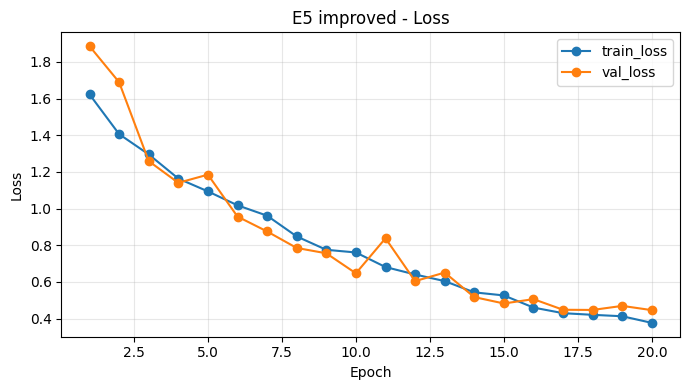

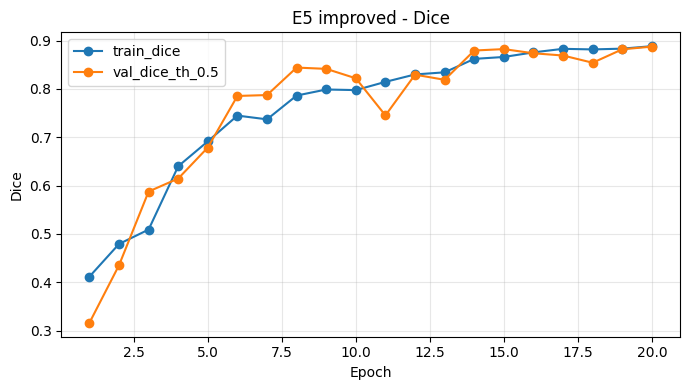

In [15]:
fig, ax = plt.subplots(1, 1, figsize=(7, 4))
ax.plot(history_df["epoch"], history_df["train_loss"], marker="o", label="train_loss")
ax.plot(history_df["epoch"], history_df["val_loss"], marker="o", label="val_loss")
ax.set_title("E5 improved - Loss")
ax.set_xlabel("Epoch")
ax.set_ylabel("Loss")
ax.grid(True, alpha=0.3)
ax.legend()
fig.tight_layout()
loss_curve_png_path = FIGURES_ROOT / "E5_improved_training_loss_curve.png"
fig.savefig(loss_curve_png_path, dpi=150, bbox_inches="tight")
plt.show()

fig, ax = plt.subplots(1, 1, figsize=(7, 4))
ax.plot(history_df["epoch"], history_df["train_dice"], marker="o", label="train_dice")
ax.plot(history_df["epoch"], history_df["val_dice_threshold_05"], marker="o", label="val_dice_th_0.5")
ax.set_title("E5 improved - Dice")
ax.set_xlabel("Epoch")
ax.set_ylabel("Dice")
ax.grid(True, alpha=0.3)
ax.legend()
fig.tight_layout()
dice_curve_png_path = FIGURES_ROOT / "E5_improved_dice_curve.png"
fig.savefig(dice_curve_png_path, dpi=150, bbox_inches="tight")
plt.show()

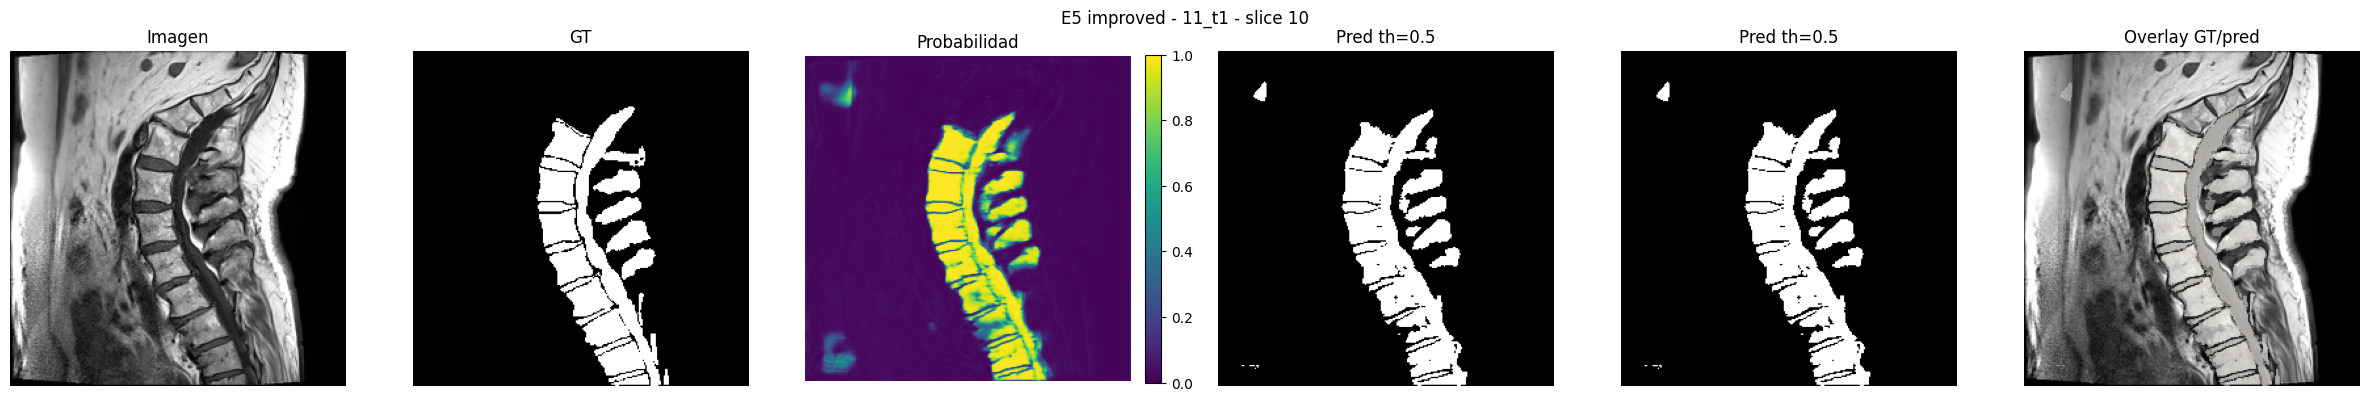

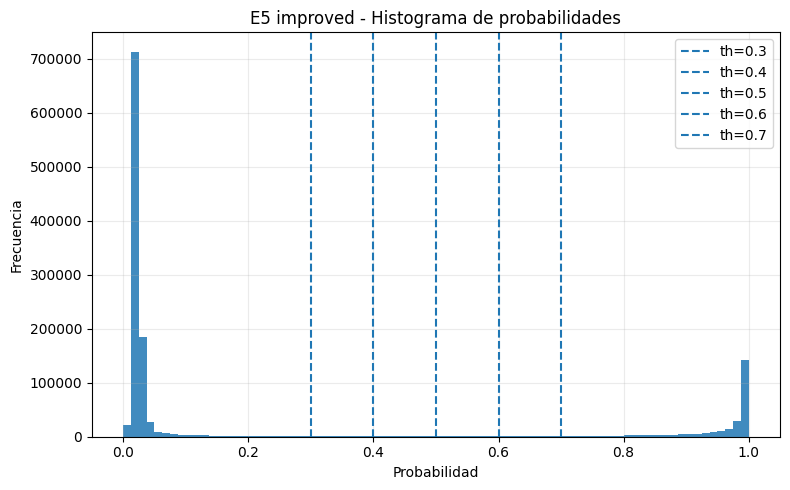

Loss curve: /content/drive/MyDrive/PFI_MVP/figures/E5_improved_training_loss_curve.png
Dice curve: /content/drive/MyDrive/PFI_MVP/figures/E5_improved_dice_curve.png
Prediction example: /content/drive/MyDrive/PFI_MVP/figures/E5_improved_prediction_example.png
Probability histogram: /content/drive/MyDrive/PFI_MVP/figures/E5_improved_probability_histogram.png


In [16]:
example = inference_items[0]
pred_05 = (example["prob"] >= 0.5).astype(np.float32)
pred_best = (example["prob"] >= best_threshold).astype(np.float32)

fig, axes = plt.subplots(1, 6, figsize=(24, 4))
axes[0].imshow(example["image"], cmap="gray", vmin=0, vmax=1)
axes[0].set_title("Imagen")
axes[1].imshow(example["gt"], cmap="gray", vmin=0, vmax=1)
axes[1].set_title("GT")
im = axes[2].imshow(example["prob"], cmap="viridis", vmin=0, vmax=1)
axes[2].set_title("Probabilidad")
fig.colorbar(im, ax=axes[2], fraction=0.046, pad=0.04)
axes[3].imshow(pred_05, cmap="gray", vmin=0, vmax=1)
axes[3].set_title("Pred th=0.5")
axes[4].imshow(pred_best, cmap="gray", vmin=0, vmax=1)
axes[4].set_title(f"Pred th={best_threshold}")
axes[5].imshow(example["image"], cmap="gray", vmin=0, vmax=1)
axes[5].imshow(np.ma.masked_where(example["gt"] == 0, example["gt"]), cmap="Greens", alpha=0.45)
axes[5].imshow(np.ma.masked_where(pred_best == 0, pred_best), cmap="Reds", alpha=0.35)
axes[5].set_title("Overlay GT/pred")
for ax in axes:
    ax.axis("off")
fig.suptitle(f"E5 improved - {example['case_id']} - slice {example['slice_index']}")
fig.tight_layout()
prediction_png_path = FIGURES_ROOT / "E5_improved_prediction_example.png"
fig.savefig(prediction_png_path, dpi=150, bbox_inches="tight")
plt.show()

all_probs = np.concatenate([item["prob"].ravel() for item in inference_items])
fig, ax = plt.subplots(1, 1, figsize=(8, 5))
ax.hist(all_probs, bins=80, range=(0, 1), alpha=0.85)
for threshold in THRESHOLDS:
    ax.axvline(threshold, linestyle="--", linewidth=1.5, label=f"th={threshold}")
ax.set_title("E5 improved - Histograma de probabilidades")
ax.set_xlabel("Probabilidad")
ax.set_ylabel("Frecuencia")
ax.legend()
ax.grid(True, alpha=0.25)
fig.tight_layout()
probability_histogram_png_path = FIGURES_ROOT / "E5_improved_probability_histogram.png"
fig.savefig(probability_histogram_png_path, dpi=150, bbox_inches="tight")
plt.show()

print("Loss curve:", loss_curve_png_path)
print("Dice curve:", dice_curve_png_path)
print("Prediction example:", prediction_png_path)
print("Probability histogram:", probability_histogram_png_path)

## 12. Reporte JSON

In [17]:
th05 = threshold_summary_df[np.isclose(threshold_summary_df["threshold"], 0.5)].iloc[0]
best_row = threshold_summary_df[np.isclose(threshold_summary_df["threshold"], best_threshold)].iloc[0]
pred_fg_05 = float(th05["pred_foreground_ratio_mean"])

collapse_note = "sin colapso foreground evidente en th=0.5"
if pred_fg_05 > 0.80:
    collapse_note = "persiste posible colapso a foreground en th=0.5"
elif pred_fg_05 < 0.01:
    collapse_note = "posible colapso a background en th=0.5"

validation_report = {
    "n_cases": int(len(selected_df)),
    "train_cases": int(len(train_dataset)),
    "validation_cases": int(len(val_dataset)),
    "modality": MODALITY_FILTER,
    "epochs": EPOCHS,
    "batch_size": BATCH_SIZE,
    "device": str(DEVICE),
    "train_foreground_ratio": float(train_foreground_ratio),
    "pos_weight": float(pos_weight_value),
    "best_threshold": float(best_threshold),
    "dice_threshold_05": float(th05["dice_mean"]),
    "dice_best_threshold": float(best_row["dice_mean"]),
    "iou_threshold_05": float(th05["iou_mean"]),
    "iou_best_threshold": float(best_row["iou_mean"]),
    "pred_foreground_ratio_threshold_05": pred_fg_05,
    "collapse_note": collapse_note,
    "comparison_against_baseline": comparison,
    "exports": {
        "selected_cases": str(selected_cases_csv_path),
        "split": str(split_csv_path),
        "history": str(history_csv_path),
        "threshold_diagnostics": str(threshold_diagnostics_csv_path),
        "threshold_summary": str(threshold_summary_csv_path),
        "comparison": str(comparison_csv_path),
        "best_model": str(best_model_path),
        "last_model": str(last_model_path),
        "loss_curve": str(loss_curve_png_path),
        "dice_curve": str(dice_curve_png_path),
        "prediction_example": str(prediction_png_path),
        "probability_histogram": str(probability_histogram_png_path),
    },
}

validation_report_path = IMPROVED_ROOT / "E5_improved_validation_report.json"
validation_report_path.write_text(json.dumps(validation_report, indent=2), encoding="utf-8")
print("Reporte JSON:", validation_report_path)
print(json.dumps(validation_report, indent=2))

Reporte JSON: /content/drive/MyDrive/PFI_MVP/results/E5_baseline_mejorado_binario/E5_improved_validation_report.json
{
  "n_cases": 100,
  "train_cases": 80,
  "validation_cases": 20,
  "modality": "t1",
  "epochs": 20,
  "batch_size": 4,
  "device": "cpu",
  "train_foreground_ratio": 0.1809743881225586,
  "pos_weight": 4.5256437685689805,
  "best_threshold": 0.5,
  "dice_threshold_05": 0.8875295160450012,
  "dice_best_threshold": 0.8875295160450012,
  "iou_threshold_05": 0.7987920464936689,
  "iou_best_threshold": 0.7987920464936689,
  "pred_foreground_ratio_threshold_05": 0.21606063842773438,
  "collapse_note": "sin colapso foreground evidente en th=0.5",
  "comparison_against_baseline": {
    "baseline_threshold_05_dice": 0.2363595434648551,
    "baseline_threshold_05_iou": 0.1343536376966334,
    "baseline_best_threshold": 0.7,
    "baseline_best_dice": 0.3148102172762091,
    "baseline_best_iou": 0.1885398295185013,
    "improved_threshold_05_dice": 0.8875295160450012,
    "improv

## 13. Conclusion tecnica Markdown

In [18]:
recommendations = []
if validation_report["pred_foreground_ratio_threshold_05"] > 0.80 or validation_report["pred_foreground_ratio_threshold_05"] < 0.01:
    recommendations.append("Revisar perdida, balance de clases, sampling de slices y threshold porque persiste un colapso evidente.")
if comparison["improved_best_dice"] > comparison["baseline_best_dice"]:
    recommendations.append("El baseline mejorado supera al baseline inicial; conviene consolidar esta configuracion antes de pasar a multiclase.")
else:
    recommendations.append("La mejora no supera claramente al baseline inicial; conviene revisar datos, seleccion de slices y augmentations.")
if DEVICE.type == "cpu":
    recommendations.append("Repetir en GPU para permitir mas epocas y/o mas casos.")
recommendations.append("Siguiente paso posible: `06_E5_experimentos_slices_y_augmentations.ipynb` o pasar a MONAI/nnU-Net solo si el baseline queda suficientemente entendido.")

conclusion_md = f"""# Conclusion tecnica - E5 Baseline mejorado binario

## Objetivo

Se entreno un baseline binario 2D mejorado sobre slices sagitales de SPIDER para evaluar si aumenta el desempeno respecto del baseline inicial.

## Cambios respecto del baseline inicial

- Mas casos: {len(selected_df)} frente a 20 del baseline inicial.
- Split reproducible 80/20.
- Perdida `BCEWithLogitsLoss(pos_weight)` + Dice loss.
- `pos_weight` calculado desde el foreground ratio del train set.
- Entrenamiento por {EPOCHS} epocas.
- Evaluacion por thresholds {THRESHOLDS}.
- Comparacion directa contra el baseline anterior.

## Configuracion

- Modalidad: `{MODALITY_FILTER}`
- Eje sagital: {SAGITTAL_AXIS}
- Target size: {TARGET_SIZE}
- Batch size: {BATCH_SIZE}
- Device: `{DEVICE}`
- Foreground ratio train: {train_foreground_ratio:.4f}
- pos_weight: {pos_weight_value:.4f}

## Resultados

- Dice improved th 0.5: {validation_report['dice_threshold_05']:.4f}
- IoU improved th 0.5: {validation_report['iou_threshold_05']:.4f}
- Mejor threshold improved: {validation_report['best_threshold']}
- Dice improved mejor threshold: {validation_report['dice_best_threshold']:.4f}
- IoU improved mejor threshold: {validation_report['iou_best_threshold']:.4f}
- Foreground predicho th 0.5: {validation_report['pred_foreground_ratio_threshold_05']:.4f}
- Diagnostico colapso: {validation_report['collapse_note']}

## Comparacion contra baseline anterior

- Dice baseline th 0.5: {comparison['baseline_threshold_05_dice']:.4f}
- Dice baseline mejor threshold: {comparison['baseline_best_dice']:.4f}
- Dice improved th 0.5: {comparison['improved_threshold_05_dice']:.4f}
- Dice improved mejor threshold: {comparison['improved_best_dice']:.4f}
- IoU baseline mejor threshold: {comparison['baseline_best_iou']:.4f}
- IoU improved mejor threshold: {comparison['improved_best_iou']:.4f}

## Evidencias exportadas

- Casos seleccionados: `{selected_cases_csv_path}`
- Split: `{split_csv_path}`
- History: `{history_csv_path}`
- Diagnostico thresholds: `{threshold_diagnostics_csv_path}`
- Resumen thresholds: `{threshold_summary_csv_path}`
- Comparacion: `{comparison_csv_path}`
- Mejor modelo: `{best_model_path}`
- Ultimo modelo: `{last_model_path}`
- Reporte JSON: `{validation_report_path}`

## Limitaciones

- Segmentacion binaria.
- Un unico slice sagital por volumen.
- Sin multiclase, axial, nnU-Net ni backend.
- La seleccion de slices sigue siendo simple y puede no capturar toda la anatomia.

## Recomendacion para proximo paso

{chr(10).join("- " + rec for rec in recommendations)}
"""

conclusion_path = DOCS_ROOT / "E5_baseline_mejorado_binario_conclusion.md"
conclusion_path.write_text(conclusion_md, encoding="utf-8")
print(conclusion_md)
print("Conclusion:", conclusion_path)

# Conclusion tecnica - E5 Baseline mejorado binario

## Objetivo

Se entreno un baseline binario 2D mejorado sobre slices sagitales de SPIDER para evaluar si aumenta el desempeno respecto del baseline inicial.

## Cambios respecto del baseline inicial

- Mas casos: 100 frente a 20 del baseline inicial.
- Split reproducible 80/20.
- Perdida `BCEWithLogitsLoss(pos_weight)` + Dice loss.
- `pos_weight` calculado desde el foreground ratio del train set.
- Entrenamiento por 20 epocas.
- Evaluacion por thresholds [0.3, 0.4, 0.5, 0.6, 0.7].
- Comparacion directa contra el baseline anterior.

## Configuracion

- Modalidad: `t1`
- Eje sagital: 2
- Target size: (256, 256)
- Batch size: 4
- Device: `cpu`
- Foreground ratio train: 0.1810
- pos_weight: 4.5256

## Resultados

- Dice improved th 0.5: 0.8875
- IoU improved th 0.5: 0.7988
- Mejor threshold improved: 0.5
- Dice improved mejor threshold: 0.8875
- IoU improved mejor threshold: 0.7988
- Foreground predicho th 0.5: 0.2161
- Diagnostico colap

## 14. Criterio de aceptacion

El notebook es correcto si usa mas casos que el baseline inicial, entrena en GPU si esta disponible, usa perdida con manejo explicito del desbalance, calcula Dice/IoU por threshold, exporta metricas/figuras/modelos/conclusion y compara contra el baseline inicial.

No avanzar todavia a multiclase, axial, nnU-Net ni integracion backend.